Mini-Projeto Avaliativo — Reconhecimento de Dígitos Manuscritos com IA

## Desenvolvimento de IA para Análise Preditiva — Módulo 2

Este projeto apresenta um pipeline completo de classificação multiclasse utilizando o conjunto de dados MNIST.

Serão comparados três modelos de aprendizado de máquina:

1. K-Nearest Neighbors — KNN;
2. Random Forest;
3. Multi-Layer Perceptron — MLP.

O projeto contempla:

- carregamento e compreensão dos dados;
- análise exploratória;
- divisão entre treino, validação e teste;
- normalização dos pixels;
- treinamento de modelos clássicos e de aprendizado profundo;
- comparação de métricas;
- análise de erros;
- avaliação de generalização;
- simulação de classes ocultas;
- teste com imagem própria;
- documentação dos resultados.

FASE 1 — PREPARAÇÃO E ANÁLISE EXPLORATÓRIA


Nesta fase será realizada a preparação inicial do ambiente e a análise do conjunto de dados MNIST.

O MNIST possui imagens em escala de cinza de dígitos manuscritos de 0 a 9.

Cada imagem possui:

- 28 pixels de largura;
- 28 pixels de altura;
- 784 pixels no total.

O objetivo inicial é compreender a estrutura dos dados antes de iniciar o treinamento dos modelos.


1.1 — Importação das bibliotecas

In [82]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


1.2 — Carregamento do conjunto MNIST


Por meio da função `fetch_openml`.

As imagens serão armazenadas em `X` e os respectivos rótulos, que representam os números de 0 a 9, serão armazenados em `y`.



In [83]:
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data
y = mnist.target.astype(np.int32)

print("MNIST carregado com sucesso.")

MNIST carregado com sucesso.


1.3 — Verificação das dimensões


Nesta etapa serão verificadas as dimensões das variáveis:

- `X`: imagens;
- `y`: rótulos das imagens.

Esperamos encontrar:

- 70.000 imagens;
- 784 características por imagem;
- 70.000 rótulos.


In [84]:
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (70000, 784)
Dimensão de y: (70000,)


1.4 — Identificação das classes



O problema é de classificação multiclasse.

As classes representam os dígitos manuscritos de 0 a 9.

Classes Existentes


In [85]:
classes = np.unique(y)

print("Classes existentes:", classes)
print("Quantidade de classes:", len(classes))

Classes existentes: [0 1 2 3 4 5 6 7 8 9]
Quantidade de classes: 10


1.5 — Distribuição das classes


Será analisada a quantidade de exemplos existente em cada classe.

Essa verificação é importante para observar se o conjunto apresenta distribuição equilibrada entre os dígitos.


,Classe,Quantidade
0,0,6903
1,1,7877
2,2,6990
3,3,7141
4,4,6824
5,5,6313
6,6,6876
7,7,7293
8,8,6825
9,9,6958


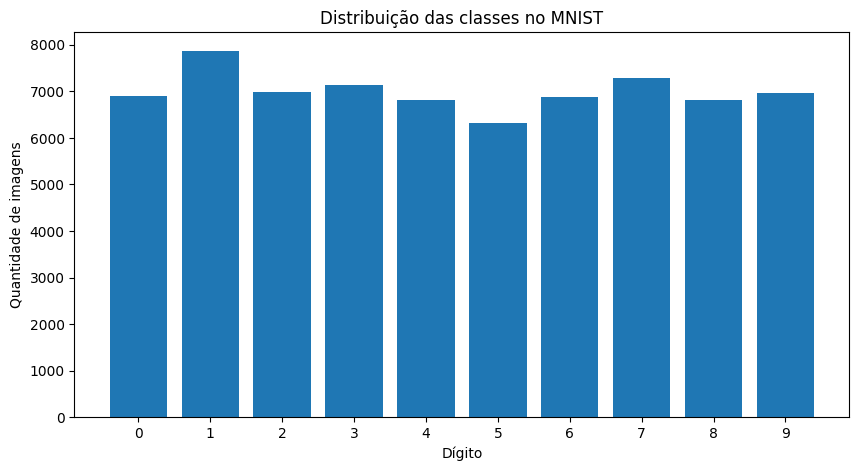

In [86]:
valores_classes, quantidades_classes = np.unique(
    y,
    return_counts=True
)

distribuicao_classes = pd.DataFrame({
    "Classe": valores_classes,
    "Quantidade": quantidades_classes
})

display(distribuicao_classes)

plt.figure(figsize=(10, 5))
plt.bar(
    distribuicao_classes["Classe"].astype(str),
    distribuicao_classes["Quantidade"]
)

plt.title("Distribuição das classes no MNIST")
plt.xlabel("Dígito")
plt.ylabel("Quantidade de imagens")
plt.show()


1.6 — Visualização de exemplos

As imagens serão apresentadas para confirmar visualmente que o conjunto contém dígitos manuscritos em escala de cinza.

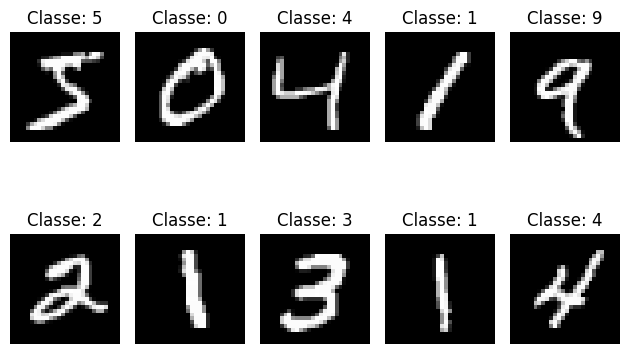

In [87]:
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap="gray")
    plt.title(f"Classe: {y[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


1.7 — Verificação da quantidade de características

Cada imagem possui 28 × 28 pixels:

28 × 28 = 784 características.

Por isso, cada imagem aparece inicialmente como um vetor com 784 valores.

In [88]:
print("Quantidade de características por imagem:", X.shape[1])
print("Cálculo esperado:", 28 * 28)

Quantidade de características por imagem: 784
Cálculo esperado: 784


FASE 2 — Divisão e normalização dos dados

Os dados serão divididos em três partes:

- treino: utilizado para ensinar os modelos;
- validação: utilizado para comparar os modelos durante o desenvolvimento;
- teste: utilizado somente na avaliação final.

A divisão será estratificada para preservar a proporção das classes.

Depois, os pixels serão normalizados para facilitar o treinamento dos modelos.

2.1 — Divisão treino, validação e teste


In [89]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111111, random_state=42, stratify=y_temp
)

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (56000, 784) (56000,)
Validação: (7000, 784) (7000,)
Teste: (7000, 784) (7000,)


2.2 — Verificação de estratificação

A opção `stratify` é usada aqui para preservar a distribuição das classes nas partes de treino, validação e teste.

Isso evita que determinados dígitos fiquem excessivamente concentrados em apenas uma das partes do conjunto de dados.


In [90]:
print("Distribuição no treino:")
print(np.unique(y_train, return_counts=True))

print("\nDistribuição na validação:")
print(np.unique(y_val, return_counts=True))

print("\nDistribuição no teste:")
print(np.unique(y_test, return_counts=True))

Distribuição no treino:
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32), array([5523, 6301, 5592, 5713, 5459, 5051, 5500, 5835, 5460, 5566]))

Distribuição na validação:
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32), array([690, 788, 699, 714, 683, 631, 688, 729, 682, 696]))

Distribuição no teste:
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32), array([690, 788, 699, 714, 682, 631, 688, 729, 683, 696]))


2.3 — Normalização dos pixels

Os pixels originais do MNIST possuem valores entre 0 e 255.

Será aplicada uma divisão por 255 para transformar os valores para a faixa entre 0 e 1.

Essa transformação facilita o treinamento dos modelos, especialmente o MLP.

In [91]:
X_train = X_train.astype(np.float32) / 255.0
X_val = X_val.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("Normalização concluída.")

Normalização concluída.


2.4 — Verificação da normalização


Será verificado o menor e o maior valor dos pixels após a normalização.

O resultado esperado é:

- valor mínimo próximo de 0;
- valor máximo igual ou próximo de 1.

Valor mínimo: 0.0
Valor máximo: 1.0
Primeiros 20 pixels:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


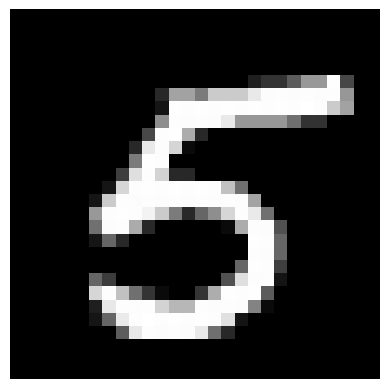

In [92]:
print("Valor mínimo:", X_train.min())
print("Valor máximo:", X_train.max())
print("Primeiros 20 pixels:")
print(X_train[0][:20])

plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.axis("off")
plt.show()


2.5 — Justificativa da normalização

A normalização transforma os valores dos pixels de uma escala de 0 a 255 para uma escala de 0 a 1. Essa transformação facilita o treinamento dos modelos, principalmente da rede neural MLP, contribuindo para maior estabilidade numérica e melhor desempenho.

FASE 3 — Treinamento dos modelos

## 1. KNN

O K-Nearest Neighbors classifica uma imagem observando as imagens mais próximas no conjunto de treinamento.

## 2. Random Forest

O Random Forest utiliza várias árvores de decisão para realizar a classificação.

## 3. MLP

O Multi-Layer Perceptron é uma rede neural artificial capaz de aprender relações mais complexas entre os pixels e os dígitos.

Os três modelos receberão os mesmos dados de treinamento e serão avaliados no mesmo conjunto de validação.

3.1 — Treinamento do KNN


In [93]:
inicio_knn = time.time()

knn = KNeighborsClassifier(
    n_neighbors=3,
    n_jobs=-1
)

knn.fit(X_train, y_train)

tempo_treino_knn = time.time() - inicio_knn

print("KNN treinado com sucesso.")
print(f"Tempo de treinamento: {tempo_treino_knn:.2f} segundos")

KNN treinado com sucesso.
Tempo de treinamento: 0.02 segundos


3.2 — Treinamento do Random Forest

In [94]:
inicio_rf = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

tempo_treino_rf = time.time() - inicio_rf

print("Random Forest treinado com sucesso.")
print(f"Tempo de treinamento: {tempo_treino_rf:.2f} segundos")

Random Forest treinado com sucesso.
Tempo de treinamento: 44.44 segundos


3.3 — Treinamento do MLP

In [95]:
inicio_mlp = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=20,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp.fit(X_train, y_train)

tempo_treino_mlp = time.time() - inicio_mlp

print("MLP treinado com sucesso.")
print(f"Tempo de treinamento: {tempo_treino_mlp:.2f} segundos")

MLP treinado com sucesso.
Tempo de treinamento: 35.07 segundos


FASE 4 — Avaliação e comparação dos modelos

Nesta fase, os modelos serão avaliados utilizando o conjunto de validação.

Serão utilizadas as seguintes métricas:

- acurácia;
- precisão;
- recall;
- F1-score.

Também será medido o tempo de previsão.

A avaliação no conjunto de teste será realizada posteriormente, depois da escolha dos modelos.

4.1 — Função de avaliação

In [96]:
def avaliar_modelo(nome, modelo, X_avaliacao, y_avaliacao):
    inicio = time.time()

    previsoes = modelo.predict(X_avaliacao)

    tempo_previsao = time.time() - inicio

    acuracia = accuracy_score(y_avaliacao, previsoes)
    precisao = precision_score(
        y_avaliacao,
        previsoes,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_avaliacao,
        previsoes,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_avaliacao,
        previsoes,
        average="weighted",
        zero_division=0
    )

    return {
        "Modelo": nome,
        "Acurácia": acuracia,
        "Precisão": precisao,
        "Recall": recall,
        "F1-score": f1,
        "Tempo de previsão (s)": tempo_previsao
    }


4.2 — Avaliação dos modelos na validação

In [97]:
resultado_knn_val = avaliar_modelo(
    "KNN",
    knn,
    X_val,
    y_val
)

resultado_rf_val = avaliar_modelo(
    "Random Forest",
    rf,
    X_val,
    y_val
)

resultado_mlp_val = avaliar_modelo(
    "MLP",
    mlp,
    X_val,
    y_val
)

resultados_validacao = pd.DataFrame([
    resultado_knn_val,
    resultado_rf_val,
    resultado_mlp_val
])

display(resultados_validacao)

,Modelo,Acurácia,Precisão,Recall,F1-score,Tempo de previsão (s)
0,KNN,0.972857,0.973024,0.972857,0.972823,28.739047
1,Random Forest,0.970143,0.970200,0.970143,0.970139,0.296008
2,MLP,0.975000,0.974990,0.975000,0.974969,0.038062


4.3 — Avaliação final no conjunto de teste

Após a comparação na validação, os três modelos serão avaliados no conjunto de teste.

O conjunto de teste representa dados que não foram utilizados diretamente no treinamento.

In [98]:
resultado_knn_teste = avaliar_modelo(
    "KNN",
    knn,
    X_test,
    y_test
)

resultado_rf_teste = avaliar_modelo(
    "Random Forest",
    rf,
    X_test,
    y_test
)

resultado_mlp_teste = avaliar_modelo(
    "MLP",
    mlp,
    X_test,
    y_test
)

resultados_teste = pd.DataFrame([
    resultado_knn_teste,
    resultado_rf_teste,
    resultado_mlp_teste
])

display(resultados_teste)

,Modelo,Acurácia,Precisão,Recall,F1-score,Tempo de previsão (s)
0,KNN,0.972286,0.972593,0.972286,0.972252,28.377922
1,Random Forest,0.966857,0.966980,0.966857,0.966871,0.292078
2,MLP,0.977000,0.977026,0.977000,0.976988,0.033483


4.4 — Comparação dos resultados

A comparação deve considerar não somente a acurácia, mas também:

- precisão;
- recall;
- F1-score;
- tempo de treinamento;
- tempo de previsão;
- complexidade do modelo.

Um modelo com boa acurácia, mas alto custo computacional, pode ser menos adequado dependendo da aplicação.

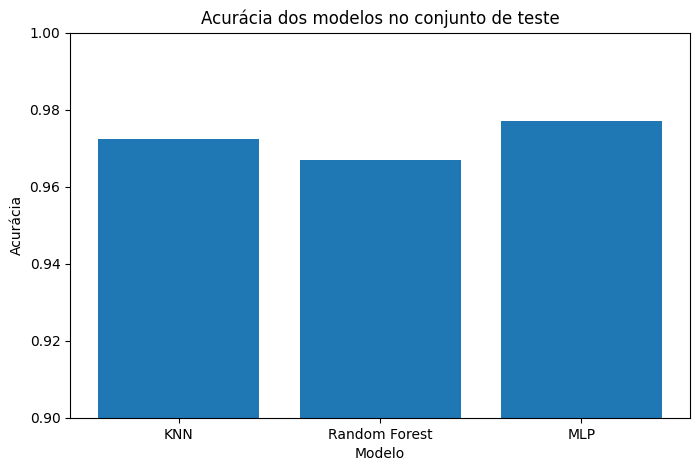

In [99]:
plt.figure(figsize=(8, 5))

plt.bar(
    resultados_teste["Modelo"],
    resultados_teste["Acurácia"]
)

plt.ylim(0.90, 1.00)
plt.title("Acurácia dos modelos no conjunto de teste")
plt.xlabel("Modelo")
plt.ylabel("Acurácia")
plt.show()


4.5 — Relatórios de classificação

Será apresentado o relatório detalhado de cada modelo.

As métricas serão calculadas por classe, permitindo observar quais dígitos são mais fáceis ou mais difíceis de classificar.

In [100]:
modelos = {
    "KNN": knn,
    "Random Forest": rf,
    "MLP": mlp
}

for nome, modelo in modelos.items():
    print("=" * 70)
    print(f"RELATÓRIO DE CLASSIFICAÇÃO — {nome}")
    print("=" * 70)

    previsoes = modelo.predict(X_test)

    print(
        classification_report(
            y_test,
            previsoes,
            zero_division=0
        )
    )


RELATÓRIO DE CLASSIFICAÇÃO — KNN
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       690
           1       0.96      1.00      0.98       788
           2       0.99      0.98      0.98       699
           3       0.97      0.97      0.97       714
           4       0.97      0.96      0.97       682
           5       0.97      0.97      0.97       631
           6       0.98      0.99      0.98       688
           7       0.97      0.97      0.97       729
           8       1.00      0.93      0.96       683
           9       0.94      0.97      0.95       696

    accuracy                           0.97      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.97      0.97      0.97      7000

RELATÓRIO DE CLASSIFICAÇÃO — Random Forest
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       690
           1       0.98      0.99      0.99       788
  

4.6 — Matrizes de confusão

A matriz de confusão mostra a quantidade de previsões corretas e incorretas para cada classe.

Ela ajuda a identificar quais dígitos são confundidos entre si.

<Figure size 700x600 with 0 Axes>

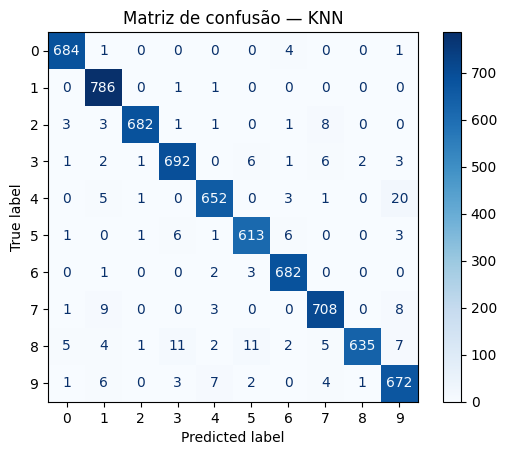

<Figure size 700x600 with 0 Axes>

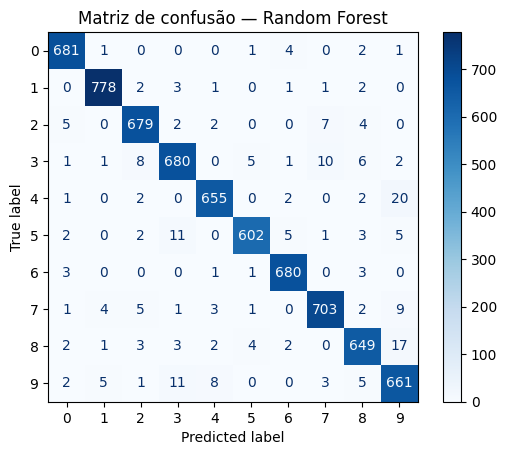

<Figure size 700x600 with 0 Axes>

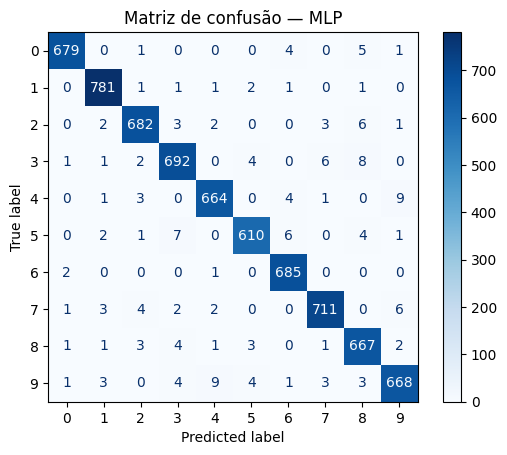

In [101]:
for nome, modelo in modelos.items():
    previsoes = modelo.predict(X_test)

    matriz = confusion_matrix(y_test, previsoes)

    plt.figure(figsize=(7, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=np.arange(10)
    )

    disp.plot(cmap="Blues", values_format="d")

    plt.title(f"Matriz de confusão — {nome}")
    plt.show()


4.7 — Análise de erros

Alguns dígitos manuscritos possuem formatos semelhantes.

Por isso, é esperado que ocorram confusões entre determinadas classes, como:

- 4 e 9;
- 3 e 5;
- 5 e 8;
- 7 e 9.

A matriz de confusão permite identificar quais confusões realmente ocorreram nos resultados obtidos.


In [102]:
for nome, modelo in modelos.items():
    previsoes = modelo.predict(X_test)
    matriz = confusion_matrix(y_test, previsoes)

    matriz_sem_diagonal = matriz.copy()
    np.fill_diagonal(matriz_sem_diagonal, 0)

    indice_maior = np.unravel_index(
        np.argmax(matriz_sem_diagonal),
        matriz_sem_diagonal.shape
    )

    classe_real = indice_maior[0]
    classe_prevista = indice_maior[1]
    quantidade = matriz_sem_diagonal[indice_maior]

    print(f"{nome}:")
    print(
        f"Maior confusão: {classe_real} "
        f"→ {classe_prevista} "
        f"({quantidade} ocorrências)"
    )
    print()


KNN:
Maior confusão: 4 → 9 (20 ocorrências)

Random Forest:
Maior confusão: 4 → 9 (20 ocorrências)

MLP:
Maior confusão: 4 → 9 (9 ocorrências)



FASE 5 — Generalização e cenário de classes ocultas


Nesta fase será simulado um cenário em que o modelo foi treinado sem visualizar algumas classes.

As classes 4 e 7 serão ocultadas durante o treinamento.

Depois, o modelo será testado justamente com imagens dessas classes.

O objetivo é observar como o modelo se comporta diante de classes que não estavam presentes no treinamento.


5.1 — Definição das classes ocultas


In [103]:
classes_ocultas = np.array([4, 7])

print("Classes ocultas:", classes_ocultas)
print("Tipo dos dados:", classes_ocultas.dtype)

Classes ocultas: [4 7]
Tipo dos dados: int64


5.2 — Criação do conjunto de treinamento sem as classes 4 e 7

In [104]:
mascara_treino_sem_ocultas = ~np.isin(
    y_train,
    classes_ocultas
)

X_train_sem_ocultas = X_train[mascara_treino_sem_ocultas]
y_train_sem_ocultas = y_train[mascara_treino_sem_ocultas]

print("Novo X_train:", X_train_sem_ocultas.shape)
print("Novo y_train:", y_train_sem_ocultas.shape)
print("Classes presentes:", np.unique(y_train_sem_ocultas))

Novo X_train: (44706, 784)
Novo y_train: (44706,)
Classes presentes: [0 1 2 3 5 6 8 9]


5.3 — Treinamento do MLP sem as classes 4 e 7

In [105]:
mlp_oculto = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=20,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

inicio_mlp_oculto = time.time()

mlp_oculto.fit(
    X_train_sem_ocultas,
    y_train_sem_ocultas
)

tempo_mlp_oculto = time.time() - inicio_mlp_oculto

print("MLP com classes ocultas treinado.")
print(f"Tempo de treinamento: {tempo_mlp_oculto:.2f} segundos")
print("Classes aprendidas pelo modelo:", mlp_oculto.classes_)


MLP com classes ocultas treinado.
Tempo de treinamento: 29.63 segundos
Classes aprendidas pelo modelo: [0 1 2 3 5 6 8 9]


5.4 — Criação do conjunto de teste contendo somente as classes ocultas

Agora serão selecionadas somente as imagens dos dígitos 4 e 7.

Essas imagens não foram apresentadas ao modelo durante o treinamento.

In [106]:
mascara_teste_ocultas = np.isin(
    y_test,
    classes_ocultas
)

X_test_ocultas = X_test[mascara_teste_ocultas]
y_test_ocultas = y_test[mascara_teste_ocultas]

print("X_test_ocultas:", X_test_ocultas.shape)
print("y_test_ocultas:", y_test_ocultas.shape)
print("Classes reais:", np.unique(y_test_ocultas))

X_test_ocultas: (1411, 784)
y_test_ocultas: (1411,)
Classes reais: [4 7]


5.5 — Previsão das classes ocultas

Como essas classes não fizeram parte do treinamento, o modelo não deverá reconhecê-las corretamente como novas classes.

Ele provavelmente tentará classificá-las como alguma das classes conhecidas.


In [107]:
y_pred_oculto = mlp_oculto.predict(X_test_ocultas)

print("Classes reais:", np.unique(y_test_ocultas))
print("Classes previstas:", np.unique(y_pred_oculto))

print("\nRelatório de classificação:")
print(
    classification_report(
        y_test_ocultas,
        y_pred_oculto,
        labels=classes_ocultas,
        zero_division=0
    )
)


Classes reais: [4 7]
Classes previstas: [0 1 2 3 5 6 8 9]

Relatório de classificação:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00     682.0
           7       0.00      0.00      0.00     729.0

   micro avg       0.00      0.00      0.00    1411.0
   macro avg       0.00      0.00      0.00    1411.0
weighted avg       0.00      0.00      0.00    1411.0



5.6 — Análise das previsões das classes ocultas

Será analisado para quais classes conhecidas o modelo direcionou as imagens das classes 4 e 7.

Esse resultado demonstra uma limitação importante dos classificadores tradicionais:

eles normalmente escolhem uma das classes conhecidas, mesmo quando recebem uma imagem de uma classe que não foi apresentada durante o treinamento.

In [108]:
for classe in classes_ocultas:
    mascara_classe = y_test_ocultas == classe

    previsoes_classe = y_pred_oculto[mascara_classe]

    valores, quantidades = np.unique(
        previsoes_classe,
        return_counts=True
    )

    print(f"Classe real {classe}:")
    print(dict(zip(valores, quantidades)))
    print()

Classe real 4:
{np.int32(1): np.int64(3), np.int32(2): np.int64(21), np.int32(3): np.int64(2), np.int32(5): np.int64(5), np.int32(6): np.int64(30), np.int32(8): np.int64(31), np.int32(9): np.int64(590)}

Classe real 7:
{np.int32(0): np.int64(4), np.int32(1): np.int64(23), np.int32(2): np.int64(87), np.int32(3): np.int64(127), np.int32(5): np.int64(3), np.int32(8): np.int64(5), np.int32(9): np.int64(480)}



5.7 — Limitação observada

O experimento mostra que o modelo não possui, automaticamente, a capacidade de dizer:

“Não conheço esta classe”.

Em vez disso, ele tende a escolher uma das classes disponíveis no treinamento.

Para detectar classes desconhecidas seria necessário utilizar técnicas específicas de:

- detecção de novidade;
- classificação aberta;
- estimativa de incerteza;
- detecção de anomalias;
- modelos treinados para rejeitar previsões pouco confiáveis.

FASE 6 — Teste com imagem própria

Nesta fase será realizada uma previsão utilizando uma imagem externa de um dígito manuscrito.

A imagem deverá ser preparada para possuir as mesmas características das imagens MNIST:

- escala de cinza;
- tamanho de 28 × 28 pixels;
- fundo e contraste semelhantes;
- vetor final com 784 características;
- valores normalizados entre 0 e 1.


In [109]:
from google.colab import drive

drive.mount('/content/drive')

# Caminho da imagem no Google Drive
nome_arquivo = "/content/drive/MyDrive/MNIST/numero4.jpeg"

print("Arquivo utilizado:", nome_arquivo)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Arquivo utilizado: /content/drive/MyDrive/MNIST/numero4.jpeg


6.2 — Preparação da imagem



A imagem será:

1. aberta;
2. convertida para escala de cinza;
3. redimensionada para 28 × 28 pixels;
4. convertida em vetor;
5. normalizada;
6. apresentada ao modelo.

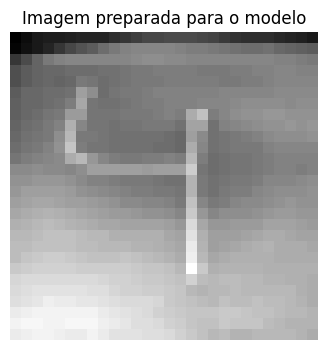

Dimensão final: (1, 784)
Valor mínimo: 0.22352941
Valor máximo: 0.4627451


In [110]:
imagem_original = Image.open(nome_arquivo)

imagem_cinza = imagem_original.convert("L")

imagem_28 = imagem_cinza.resize((28, 28))

imagem_array = np.array(imagem_28)

# Inversão para aproximar o padrão MNIST:
# fundo escuro e dígito claro
imagem_array = 255 - imagem_array

imagem_normalizada = imagem_array.astype(np.float32) / 255.0

imagem_vetor = imagem_normalizada.reshape(1, 784)

plt.figure(figsize=(4, 4))
plt.imshow(imagem_normalizada, cmap="gray")
plt.title("Imagem preparada para o modelo")
plt.axis("off")
plt.show()

print("Dimensão final:", imagem_vetor.shape)
print("Valor mínimo:", imagem_vetor.min())
print("Valor máximo:", imagem_vetor.max())

6.3 — Previsão da imagem própria pelos três modelos

A mesma imagem será apresentada aos modelos KNN, Random Forest e MLP.

Será comparado o resultado de cada modelo.


In [111]:
previsao_knn_imagem = knn.predict(imagem_vetor)[0]
previsao_rf_imagem = rf.predict(imagem_vetor)[0]
previsao_mlp_imagem = mlp.predict(imagem_vetor)[0]

print("Previsão KNN:", previsao_knn_imagem)
print("Previsão Random Forest:", previsao_rf_imagem)
print("Previsão MLP:", previsao_mlp_imagem)

Previsão KNN: 2
Previsão Random Forest: 8
Previsão MLP: 3


6.4 — Probabilidades e confiança

Quando disponível, será verificada a probabilidade estimada pelos modelos.

Essa probabilidade não deve ser interpretada automaticamente como certeza absoluta.

Ela representa o grau de confiança calculado pelo modelo dentro das classes conhecidas.


In [112]:
modelos_imagem = {
    "KNN": knn,
    "Random Forest": rf,
    "MLP": mlp
}

for nome, modelo in modelos_imagem.items():
    if hasattr(modelo, "predict_proba"):
        probabilidades = modelo.predict_proba(imagem_vetor)[0]

        maior_indice = np.argmax(probabilidades)
        maior_probabilidade = probabilidades[maior_indice]

        print(
            f"{nome}: classe {modelo.classes_[maior_indice]} "
            f"com probabilidade de "
            f"{maior_probabilidade:.4f}"
        )
    else:
        print

KNN: classe 2 com probabilidade de 0.3333
Random Forest: classe 8 com probabilidade de 0.3300
MLP: classe 3 com probabilidade de 0.6923


In [113]:
conteudo_readme = """# Reconhecimento de Dígitos Manuscritos com Inteligência Artificial

## Mini-Projeto Avaliativo — Módulo 2

Projeto desenvolvido no curso Desenvolvimento de IA para Análise Preditiva — SENAC SCTEC 2026.

## Sobre o projeto

Este projeto desenvolve um pipeline de Inteligência Artificial para reconhecimento de dígitos manuscritos utilizando o conjunto de dados MNIST.

O projeto contempla preparação dos dados, análise exploratória, treinamento de modelos, avaliação, análise de erros, generalização e teste com uma imagem manuscrita própria.

## Dataset

Foi utilizado o conjunto de dados MNIST.

- 70.000 imagens
- 10 classes, de 0 a 9
- Imagens em escala de cinza
- Resolução de 28 x 28 pixels
- 784 características por imagem

Os dados foram divididos em:

- Treinamento: 56.000 imagens
- Validação: 7.000 imagens
- Teste: 7.000 imagens

Foi utilizada estratificação para preservar a distribuição das classes.

## Modelos utilizados

Foram utilizados três modelos:

- K-Nearest Neighbors (KNN)
- Random Forest
- Multi-Layer Perceptron (MLP)

## Avaliação

Os modelos foram avaliados utilizando:

- Accuracy
- Precision
- Recall
- F1-score
- Classification Report
- Matrizes de Confusão
- Análise de erros
- Tempo de treinamento
- Tempo de previsão

Entre as principais confusões observadas esteve a classificação do dígito 4 como 9.

## Generalização

Foi realizado um experimento retirando as classes 4 e 7 do treinamento.

Depois, exemplos dessas classes foram utilizados para testar o comportamento do modelo diante de classes que não estavam presentes no treinamento.

O experimento demonstrou uma limitação importante: quando uma classe não é conhecida durante o treinamento, o modelo tende a classificá-la como uma das classes que conhece.

## Teste com imagem própria

Foi realizada uma previsão utilizando uma imagem manuscrita própria.

A imagem passou por preparação para ficar compatível com o MNIST, incluindo:

- conversão para escala de cinza;
- adequação dos tons;
- recorte da região relevante;
- centralização;
- redimensionamento para 28 x 28 pixels;
- normalização;
- transformação para 784 características.

A imagem foi submetida aos três modelos treinados.

## Tecnologias

- Python
- Google Colab
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- Pillow

## Organização do projeto

O projeto foi desenvolvido em seis fases:

1. Preparação e análise exploratória
2. Divisão e normalização dos dados
3. Treinamento dos modelos
4. Avaliação e comparação
5. Generalização e classes ocultas
6. Teste com imagem própria

## Uso de Inteligência Artificial

A Inteligência Artificial generativa foi utilizada como ferramenta de apoio durante o desenvolvimento.

Seu uso ocorreu principalmente para compreender conceitos, receber explicações sobre código e bibliotecas, auxiliar na identificação e correção de erros, organizar as etapas e apoiar a documentação do projeto.

A execução do código, os testes no Google Colab e a verificação dos resultados foram realizados durante o desenvolvimento do projeto.

## Conclusão

O projeto apresenta um pipeline completo de classificação de dígitos manuscritos utilizando KNN, Random Forest e MLP.

Além da avaliação dos modelos, foram realizados experimentos de análise de erros, generalização para classes não utilizadas no treinamento e previsão de uma imagem manuscrita própria.
"""

with open("README.md", "w", encoding="utf-8") as arquivo:
    arquivo.write(conteudo_readme)

print("README.md criado com sucesso!")

README.md criado com sucesso!


In [114]:
conteudo_requirements = """numpy
pandas
matplotlib
scikit-learn
Pillow
"""

with open("requirements.txt", "w", encoding="utf-8") as arquivo:
    arquivo.write(conteudo_requirements)

print("requirements.txt criado com sucesso!")

requirements.txt criado com sucesso!
